# Linear V1 Inspection Notebook

This notebook is for interactive inspection of the current JAX implementation:
- `finit='cosine2'` initialization
- current linear solver stepping (`gksolve_with_state`)
- representative mode-growth diagnostics
- checkpoint comparison against `iteration_13_Lin` (`DM2 -> FDS`)

Run inside the mandated environment (`/system/apps/userenv/galletti/mhd`).

# Linear V1 Inspection Notebook

This notebook is for interactive inspection of the current JAX implementation:
- `finit='cosine2'` initialization
- current linear solver stepping (`gksolve_with_state`)
- representative mode-growth diagnostics
- checkpoint comparison against `iteration_13_Lin` (`DM2 -> FDS`)

Run inside the mandated environment (`/system/apps/userenv/galletti/mhd`).

In [28]:
import os
import sys

os.environ["CUDA_VISIBLE_DEVICES"] = "6"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "False"
sys.path.append("..")

In [29]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jax_geometry import load_geometry
from jax_integrals import get_integrals
from gksolver import GKParams, default_state, gksolve_with_state, init_df_cosine2
from utils import load_gkw_k_dump
from plot_utils import plot_nd

jax.config.update("jax_enable_x64", True)

BASE = "/restricteddata/ukaea/gyrokinetics/raw/iteration_13_Lin"
geom = load_geometry(BASE)

print("Loaded geometry from:", BASE)
print(
    "Grid sizes (vpar, mu, s, kx, ky):",
    len(geom["intvp"]),
    len(geom["intmu"]),
    len(geom["ints"]),
    len(geom["kxrh"]),
    len(geom["krho"]),
)
print("ixzero, iyzero:", int(geom["ixzero"]), int(geom["iyzero"]))
print(
    "kx range:",
    float(np.min(np.asarray(geom["kxrh"]))),
    float(np.max(np.asarray(geom["kxrh"]))),
)
print(
    "ky range:",
    float(np.min(np.asarray(geom["krho"]))),
    float(np.max(np.asarray(geom["krho"]))),
)

Loaded geometry from: /restricteddata/ukaea/gyrokinetics/raw/iteration_13_Lin
Grid sizes (vpar, mu, s, kx, ky): 32 8 16 85 32
ixzero, iyzero: 42 0
kx range: -8.87631 8.87631
ky range: 0.0 0.4430323666789028


## 1) Inspect initialization (`finit='cosine2'`)

In [30]:
df0_raw = init_df_cosine2(
    geom, amp_init_real=1.0e-4, amp_init_imag=0.0, normalize_per_toroidal_mode=False
)
df0 = init_df_cosine2(
    geom, amp_init_real=1.0e-4, amp_init_imag=0.0, normalize_per_toroidal_mode=True
)

iyzero = int(geom["iyzero"])
print("df0_raw shape:", df0_raw.shape, "dtype:", df0_raw.dtype)
print("df0 (startup normalized) shape:", df0.shape)
print("max |df0_raw[..., ky=0]|:", float(jnp.max(jnp.abs(df0_raw[..., iyzero]))))
print("max |df0[..., ky=0]|:", float(jnp.max(jnp.abs(df0[..., iyzero]))))

# Verify startup mode normalization (non-zonal ky expected near 1).
phi0_raw, _ = get_integrals(df0_raw, geom)
phi0, _ = get_integrals(df0, geom)
ds = float(np.asarray(geom["ints"])[0])
amp_raw = np.sqrt(ds * np.sum(np.abs(np.asarray(phi0_raw)) ** 2, axis=(0, 1)))
amp_norm = np.sqrt(ds * np.sum(np.abs(np.asarray(phi0)) ** 2, axis=(0, 1)))
print(
    "non-zonal min/max amp after startup normalization:",
    float(np.min(amp_norm[np.arange(len(amp_norm)) != iyzero])),
    float(np.max(amp_norm[np.arange(len(amp_norm)) != iyzero])),
)

df0_raw shape: (32, 8, 16, 85, 32) dtype: complex128
df0 (startup normalized) shape: (32, 8, 16, 85, 32)
max |df0_raw[..., ky=0]|: 0.0
max |df0[..., ky=0]|: 0.0
non-zonal min/max amp after startup normalization: 0.9999999999999991 1.0000000000000007


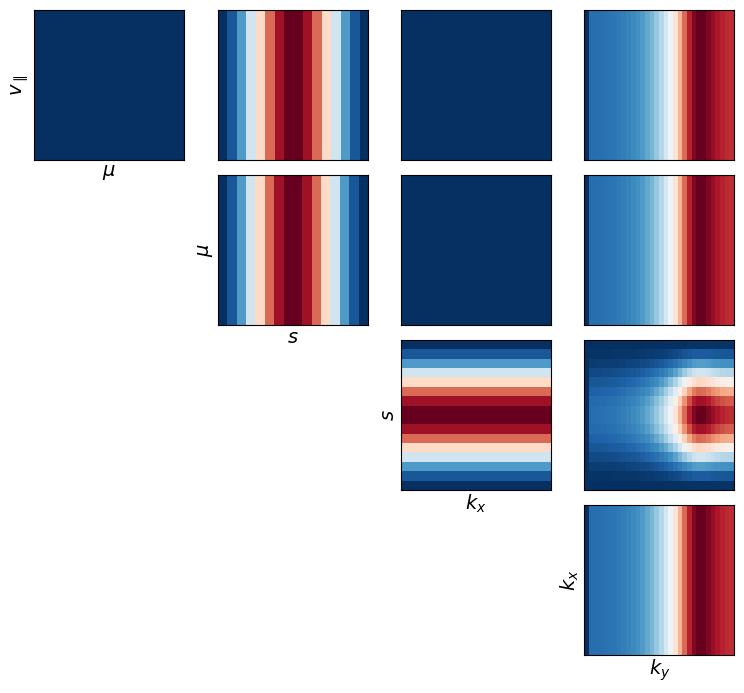

In [31]:
fig = plot_nd(np.abs(np.asarray(df0)))

## 2) Helper utilities for mode chains and stepping

In [32]:
mode_label = np.asarray(geom["mode_label"])
ixzero = int(geom["ixzero"])
iyzero = int(geom["iyzero"])


def connected_kx_indices(ky_index: int):
    lbl = int(mode_label[ixzero, ky_index])
    return np.where(mode_label[:, ky_index] == lbl)[0], lbl


def run_small_steps(df_init, nsteps=80, params=None):
    if params is None:
        params = GKParams(dt=0.01, naverage=40, disp_par=1.0, disp_x=0.1, disp_y=0.1)
    state = default_state()
    df = df_init
    phi_hist = []
    growth_hist = []

    @jax.jit
    def step_fn(current_df, current_state):
        return gksolve_with_state(current_df, geom, params, current_state)

    for _ in range(nsteps):
        df, (phi, _), state = step_fn(df, state)

        phi_hist.append(np.asarray(phi))
        growth_hist.append(float(np.asarray(state.last_growth_rate)))

    return df, np.asarray(phi_hist), np.asarray(growth_hist), state

## 3) Quick evolution from init and representative mode-growth visualization

Ran 80 small steps in 11.65s
state.step: 80 state.time: 0.8000000000000005 last_growth_rate: 0.2355597598083597


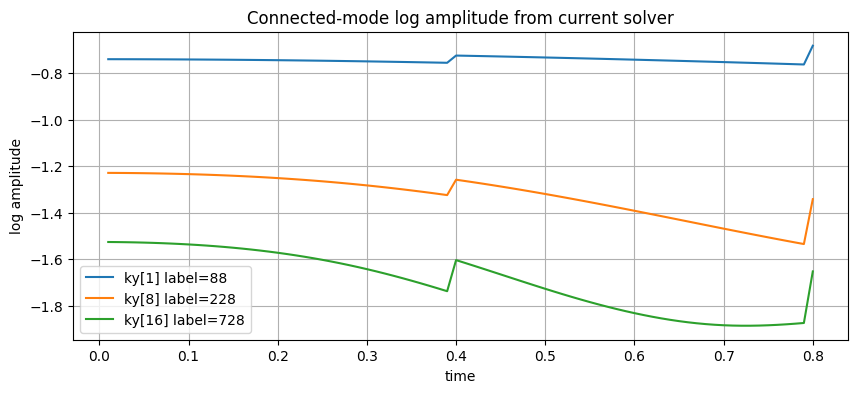

In [33]:
params = GKParams(dt=0.01, naverage=40, disp_par=1.0, disp_x=0.1, disp_y=0.1)
nsteps = 80

t0 = time.time()
df80, phi_hist, growth_hist, state80 = run_small_steps(
    df0, nsteps=nsteps, params=params
)
print(f"Ran {nsteps} small steps in {time.time()-t0:.2f}s")
print(
    "state.step:",
    int(np.asarray(state80.step)),
    "state.time:",
    float(np.asarray(state80.time)),
    "last_growth_rate:",
    float(np.asarray(state80.last_growth_rate)),
)

rep_ky = [1, 8, 16]
rep_ky = [k for k in rep_ky if k < len(geom["krho"]) and k != iyzero]

dt = params.dt
time_small = dt * np.arange(1, nsteps + 1)
ds = float(np.asarray(geom["ints"])[0])

plt.figure(figsize=(10, 4))
for ky in rep_ky:
    kx_chain, lbl = connected_kx_indices(ky)
    amp = np.sqrt(ds * np.sum(np.abs(phi_hist[:, :, kx_chain, ky]) ** 2, axis=(1, 2)))
    plt.plot(time_small, np.log(np.maximum(amp, 1e-30)), label=f"ky[{ky}] label={lbl}")
plt.xlabel("time")
plt.ylabel("log amplitude")
plt.title("Connected-mode log amplitude from current solver")
plt.legend()
plt.grid(True)
plt.show()

## 4) Evaluate against `iteration_13_Lin` checkpoints (`DM2 -> FDS`)

In [34]:
res = (
    len(geom["intvp"]),
    len(geom["intmu"]),
    len(geom["ints"]),
    len(geom["kxrh"]),
    len(geom["krho"]),
)
dm2 = load_gkw_k_dump(f"{BASE}/DM2", res)
fds = load_gkw_k_dump(f"{BASE}/FDS", res)

# DM2 at t=319.2, FDS at t=320.0 -> 80 small steps (dt=0.01)
t0 = time.time()
dm2_to_fds_pred, _, _, _ = run_small_steps(dm2, nsteps=80, params=params)
print(f"DM2->FDS prediction runtime: {time.time()-t0:.2f}s")


def rel_l2(a, b, eps=1e-30):
    na = float(jnp.linalg.norm(a - b))
    nb = float(jnp.linalg.norm(b))
    return na / max(nb, eps)


phi_pred, flux_pred = get_integrals(dm2_to_fds_pred, geom)
phi_fds, flux_fds = get_integrals(fds, geom)

print("Relative L2(df_pred, FDS):", rel_l2(dm2_to_fds_pred, fds))
print("Relative L2(phi_pred, phi_FDS):", rel_l2(phi_pred, phi_fds))

p_pred, e_pred, v_pred = [float(np.asarray(x)) for x in flux_pred]
p_ref, e_ref, v_ref = [float(np.asarray(x)) for x in flux_fds]
print("Fluxes pred (p,e,v):", p_pred, e_pred, v_pred)
print("Fluxes FDS  (p,e,v):", p_ref, e_ref, v_ref)
print(
    "Relative flux errors:",
    abs(p_pred - p_ref) / (abs(p_ref) + 1e-30),
    abs(e_pred - e_ref) / (abs(e_ref) + 1e-30),
    abs(v_pred - v_ref) / (abs(v_ref) + 1e-30),
)

DM2->FDS prediction runtime: 11.54s
Relative L2(df_pred, FDS): 8.909776831351249e-06
Relative L2(phi_pred, phi_FDS): 7.603481167677109e-06
Fluxes pred (p,e,v): 4.440892098500626e-16 38.298864734361736 9.237055564881302e-14
Fluxes FDS  (p,e,v): 6.661338147750939e-16 38.29877310593047 9.403589018575076e-14
Relative flux errors: 0.3333333333333328 2.3924638789426066e-06 0.01770956316410862


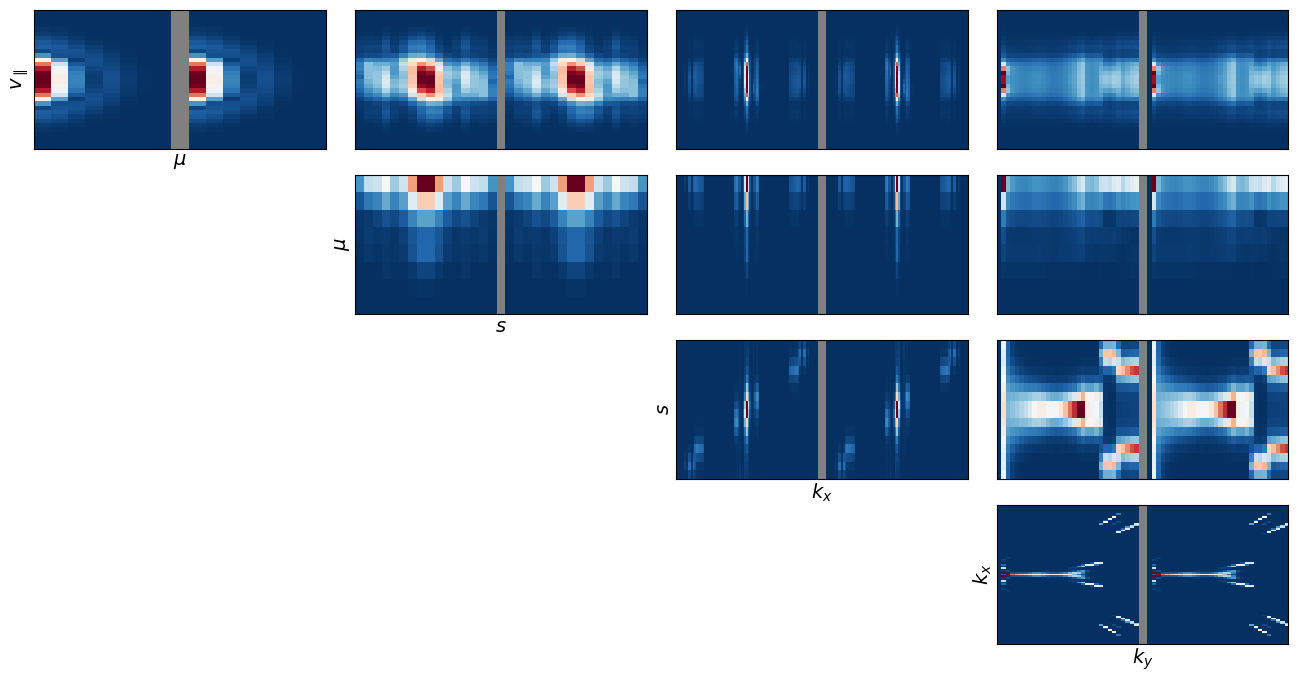

In [35]:
fig = plot_nd(np.abs(np.asarray(dm2_to_fds_pred)), np.abs(np.asarray(fds)))

## 5) Nonlinear smoke validation (`iteration_13`, dump 100 -> 101)

This section runs the nonlinear solver path (`non_linear=True`, `enable_term_iii=True`) for one 120-step window (`1.2` time units) and compares against the next GKW K-dump.

It prints pass/fail flags for the current thresholds but does **not** raise assertions, so you can inspect diagnostics even when a metric fails.

In [36]:
NONLIN_BASE = "/restricteddata/ukaea/gyrokinetics/raw/iteration_13"
geom_nl = load_geometry(NONLIN_BASE)

print("Loaded nonlinear geometry from:", NONLIN_BASE)
print(
    "Grid sizes (vpar, mu, s, kx, ky):",
    len(geom_nl["intvp"]),
    len(geom_nl["intmu"]),
    len(geom_nl["ints"]),
    len(geom_nl["kxrh"]),
    len(geom_nl["krho"]),
)
print("ixzero, iyzero:", int(geom_nl["ixzero"]), int(geom_nl["iyzero"]))

res_nl = (
    len(geom_nl["intvp"]),
    len(geom_nl["intmu"]),
    len(geom_nl["ints"]),
    len(geom_nl["kxrh"]),
    len(geom_nl["krho"]),
)

import re


def read_dump_time(dat_path):
    with open(dat_path, "r", encoding="utf-8") as f:
        text = f.read()
    m = re.search(r"TIME\s*=\s*([0-9eE+\-.]+)", text)
    if m is None:
        raise ValueError(f"TIME entry not found in {dat_path}")
    return float(m.group(1))


def rel_l2(a, b, eps=1e-30):
    na = float(jnp.linalg.norm(a - b))
    nb = float(jnp.linalg.norm(b))
    return na / max(nb, eps)


def selected_ky_representatives(iyzero, nky):
    candidates = [1, nky // 2, nky - 1]
    out = []
    for ky in candidates:
        ky = int(np.clip(ky, 0, nky - 1))
        if ky == iyzero:
            continue
        if ky not in out:
            out.append(ky)
    if not out:
        out = [int((iyzero + 1) % nky)]
    return out


def subset_mask_from_mode_chains(mode_label, ixzero, ky_list):
    nkx, nky = mode_label.shape
    mask = np.zeros((nkx, nky), dtype=bool)
    labels = []
    for ky in ky_list:
        lbl = int(mode_label[ixzero, ky])
        labels.append(lbl)
        mask[:, ky] = mode_label[:, ky] == lbl
    return mask, np.asarray(labels, dtype=np.int32)


def run_small_steps_on_geom(df_init, geometry, params, nsteps, state=None):
    if state is None:
        state = default_state()
    df = df_init

    @jax.jit
    def step_fn(current_df, current_state):
        return gksolve_with_state(current_df, geometry, params, current_state)

    phi_hist = []
    eflux_hist = []
    time_hist = []
    growth_hist = []

    for _ in range(nsteps):
        df, (phi, fluxes), state = step_fn(df, state)

        phi_hist.append(np.asarray(phi))
        eflux_hist.append(float(np.asarray(fluxes[1])))
        time_hist.append(float(np.asarray(state.time)))
        growth_hist.append(float(np.asarray(state.last_growth_rate)))

    return (
        df,
        np.asarray(phi_hist),
        np.asarray(eflux_hist),
        np.asarray(time_hist),
        np.asarray(growth_hist),
        state,
    )

Loaded nonlinear geometry from: /restricteddata/ukaea/gyrokinetics/raw/iteration_13
Grid sizes (vpar, mu, s, kx, ky): 32 8 16 85 32
ixzero, iyzero: 42 0


In [37]:
start_name = "100"
end_name = "105"

start_df = load_gkw_k_dump(f"{NONLIN_BASE}/{start_name}", res_nl)
end_df_ref = load_gkw_k_dump(f"{NONLIN_BASE}/{end_name}", res_nl)

t_start = read_dump_time(f"{NONLIN_BASE}/{start_name}.dat")
t_end = read_dump_time(f"{NONLIN_BASE}/{end_name}.dat")
nsteps = int(round((t_end - t_start) / 0.01))

params_nl = GKParams(
    dt=0.01,
    naverage=40,
    disp_par=1.0,
    disp_vp=0.2,
    disp_x=0.1,
    disp_y=0.1,
    non_linear=True,
    enable_term_iii=True,
)

state_nl0 = type(default_state())(
    time=jnp.array(t_start, dtype=jnp.float64),
    step=jnp.array(0, dtype=jnp.int32),
    accumulated_norm_factor=jnp.array(1.0, dtype=jnp.float64),
    window_start_amp=jnp.array(1.0, dtype=jnp.float64),
    last_growth_rate=jnp.array(0.0, dtype=jnp.float64),
)

print(
    f"Running nonlinear window {start_name} -> {end_name}: t={t_start:.3f} -> {t_end:.3f}, nsteps={nsteps}"
)
t0 = time.time()
pred_df_nl, phi_hist_nl, eflux_hist_nl, time_hist_nl, growth_hist_nl, state_nl = (
    run_small_steps_on_geom(
        start_df,
        geom_nl,
        params_nl,
        nsteps=nsteps,
        state=state_nl0,
    )
)
print(f"Runtime: {time.time()-t0:.2f}s")
print(
    "state.step:",
    int(np.asarray(state_nl.step)),
    "state.time:",
    float(np.asarray(state_nl.time)),
)

mode_label_nl = np.asarray(geom_nl["mode_label"], dtype=np.int32)
ixzero_nl = int(np.asarray(geom_nl["ixzero"]))
iyzero_nl = int(np.asarray(geom_nl["iyzero"]))
ky_sel_nl = selected_ky_representatives(iyzero_nl, mode_label_nl.shape[1])
subset_mask_2d_nl, subset_labels_nl = subset_mask_from_mode_chains(
    mode_label_nl, ixzero_nl, ky_sel_nl
)
subset_mask_5d_nl = subset_mask_2d_nl[None, None, None, :, :]

pred_sub = np.asarray(pred_df_nl) * subset_mask_5d_nl
ref_sub = np.asarray(end_df_ref) * subset_mask_5d_nl
subset_rel_l2_nl = rel_l2(pred_sub, ref_sub)

phi_start_nl, _ = get_integrals(start_df, geom_nl)
phi_end_pred_nl, flux_pred_nl = get_integrals(pred_df_nl, geom_nl)
phi_end_ref_nl, flux_ref_end_nl = get_integrals(end_df_ref, geom_nl)

ds = float(np.asarray(geom_nl["ints"])[0])
amp_start_nl = np.sqrt(ds * np.sum(np.abs(np.asarray(phi_start_nl)) ** 2, axis=0))
amp_end_nl = np.sqrt(ds * np.sum(np.abs(np.asarray(phi_end_pred_nl)) ** 2, axis=0))
growth_pred_nl = np.log(
    np.maximum(amp_end_nl[ixzero_nl, ky_sel_nl], 1e-30)
    / np.maximum(amp_start_nl[ixzero_nl, ky_sel_nl], 1e-30)
) / max((t_end - t_start), 1e-30)

growth_all_nl = np.loadtxt(f"{NONLIN_BASE}/growth_rates_all_modes")
time_all_nl = np.loadtxt(f"{NONLIN_BASE}/time.dat")
fluxes_all_nl = np.loadtxt(f"{NONLIN_BASE}/fluxes.dat")
i_start = int(np.argmin(np.abs(time_all_nl - t_start)))
i_end = int(np.argmin(np.abs(time_all_nl - t_end)))
i_lo = min(i_start + 1, i_end)
i_hi = max(i_start + 1, i_end)
cols_nl = subset_labels_nl - 1
growth_ref_nl = np.mean(growth_all_nl[i_lo : i_hi + 1, cols_nl], axis=0)
growth_rel_err_nl = float(
    np.max(
        np.abs(growth_pred_nl - growth_ref_nl)
        / np.maximum(np.abs(growth_ref_nl), 1e-12)
    )
)

eflux_pred_nl = float(np.asarray(flux_pred_nl[1]))
eflux_ref_nl = float(fluxes_all_nl[i_end, 1])
eflux_rel_err_nl = abs(eflux_pred_nl - eflux_ref_nl) / max(abs(eflux_ref_nl), 1e-12)

print("\nNonlinear smoke metrics:")
print("  subset_rel_l2:", subset_rel_l2_nl)
print("  growth_rel_err:", growth_rel_err_nl)
print("  eflux_rel_err:", eflux_rel_err_nl)
print("  selected ky:", ky_sel_nl)
print("  selected labels:", subset_labels_nl.tolist())

# Keep notebook informative even if thresholds are not met.
th_subset = 1.0e-1
th_growth = 1.5e-1
th_eflux = 2.0e-1
print("\nThreshold checks (informational):")
print(f"  subset_rel_l2 <= {th_subset}: {subset_rel_l2_nl <= th_subset}")
print(f"  growth_rel_err <= {th_growth}: {growth_rel_err_nl <= th_growth}")
print(f"  eflux_rel_err <= {th_eflux}: {eflux_rel_err_nl <= th_eflux}")

Running nonlinear window 100 -> 105: t=120.000 -> 126.000, nsteps=600
Runtime: 128.35s
state.step: 600 state.time: 126.00000000002707

Nonlinear smoke metrics:
  subset_rel_l2: 0.7161452681313771
  growth_rel_err: 13.779414325980348
  eflux_rel_err: 9.831890892397993
  selected ky: [1, 16, 31]
  selected labels: [88, 728, 1998]

Threshold checks (informational):
  subset_rel_l2 <= 0.1: False
  growth_rel_err <= 0.15: False
  eflux_rel_err <= 0.2: False


## 6) Nonlinear visualization: mode subset, growth, fluxes, and spectral error

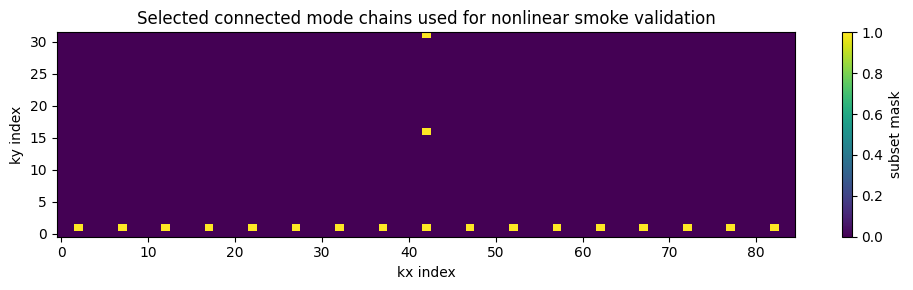

In [38]:
plt.figure(figsize=(10, 3))
plt.imshow(
    subset_mask_2d_nl.T.astype(float), aspect="auto", origin="lower", cmap="viridis"
)
plt.colorbar(label="subset mask")
plt.xlabel("kx index")
plt.ylabel("ky index")
plt.title("Selected connected mode chains used for nonlinear smoke validation")
plt.tight_layout()
plt.show()

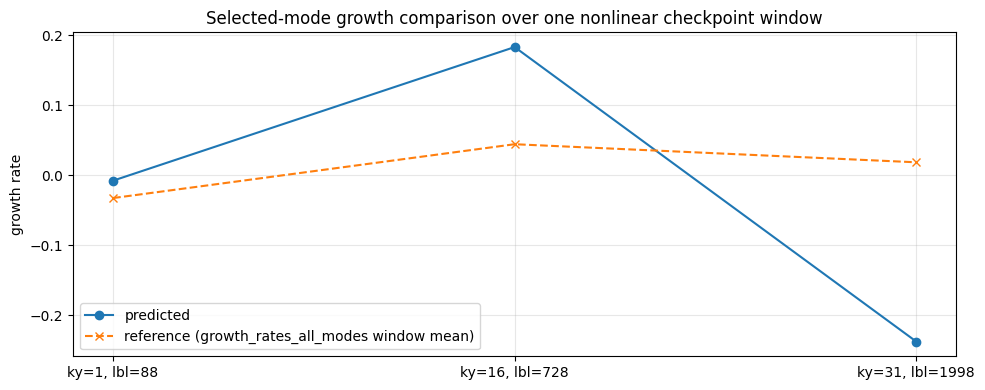

In [39]:
plt.figure(figsize=(10, 4))
x = np.arange(len(ky_sel_nl))
plt.plot(x, growth_pred_nl, "o-", label="predicted")
plt.plot(
    x, growth_ref_nl, "x--", label="reference (growth_rates_all_modes window mean)"
)
plt.xticks(x, [f"ky={ky}, lbl={lbl}" for ky, lbl in zip(ky_sel_nl, subset_labels_nl)])
plt.ylabel("growth rate")
plt.title("Selected-mode growth comparison over one nonlinear checkpoint window")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

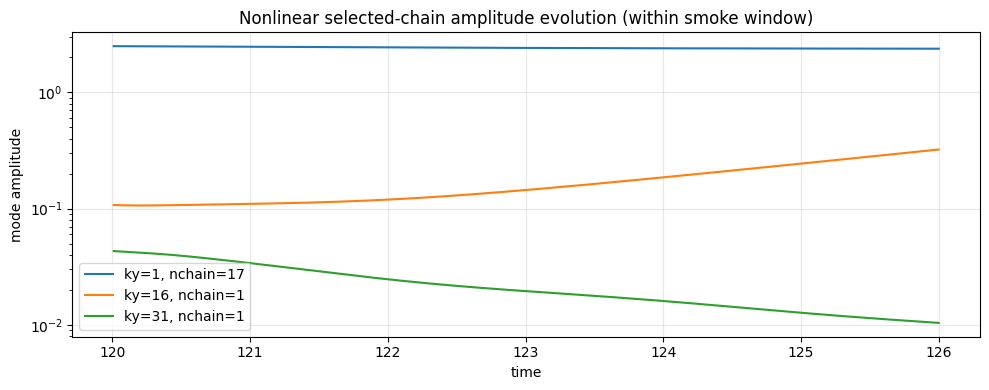

In [40]:
plt.figure(figsize=(10, 4))
for ky in ky_sel_nl:
    kx_chain = np.where(subset_mask_2d_nl[:, ky])[0]
    amp_hist = np.sqrt(
        ds * np.sum(np.abs(phi_hist_nl[:, :, kx_chain, ky]) ** 2, axis=(1, 2))
    )
    plt.plot(time_hist_nl, amp_hist, label=f"ky={ky}, nchain={len(kx_chain)}")
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("mode amplitude")
plt.title("Nonlinear selected-chain amplitude evolution (within smoke window)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

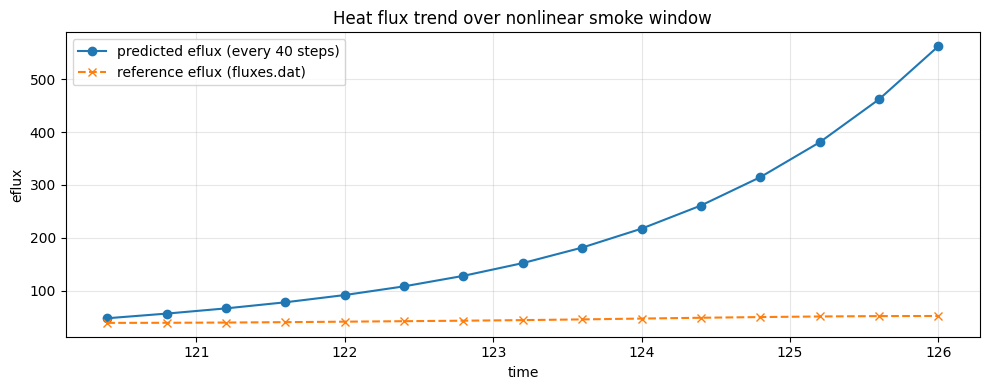

In [41]:
# Compare predicted heat flux at large-step boundaries to reference fluxes.dat
ls_idx = np.arange(39, nsteps, 40)
ls_times = t_start + 0.01 * (ls_idx + 1)
eflux_pred_ls = eflux_hist_nl[ls_idx]
ref_idx_ls = np.array(
    [int(np.argmin(np.abs(time_all_nl - t))) for t in ls_times], dtype=int
)
eflux_ref_ls = fluxes_all_nl[ref_idx_ls, 1]

plt.figure(figsize=(10, 4))
plt.plot(ls_times, eflux_pred_ls, "o-", label="predicted eflux (every 40 steps)")
plt.plot(ls_times, eflux_ref_ls, "x--", label="reference eflux (fluxes.dat)")
plt.xlabel("time")
plt.ylabel("eflux")
plt.title("Heat flux trend over nonlinear smoke window")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

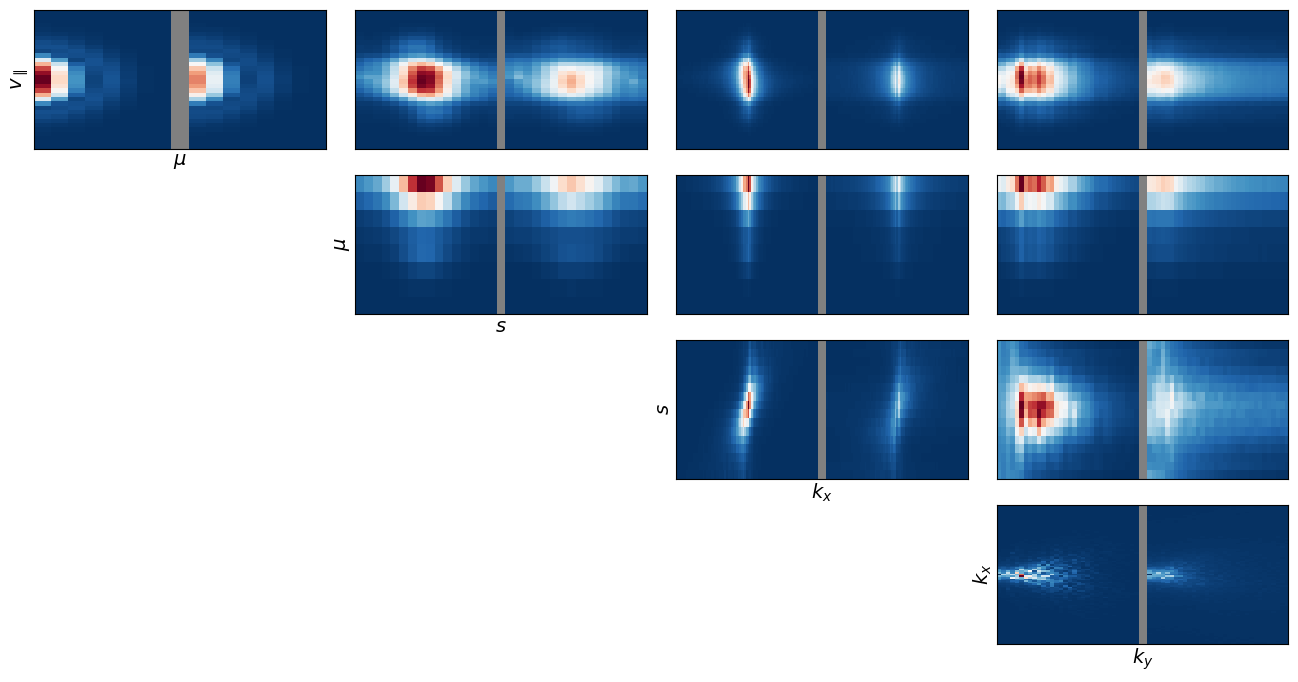

In [42]:
fig = plot_nd(np.abs(np.asarray(pred_df_nl)), np.abs(np.asarray(end_df_ref)))